In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [6]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [7]:
X = df.drop(['DEATH_EVENT'],axis = 1)
y = df['DEATH_EVENT']

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.10)

In [43]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train,y_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [44]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear',random_state = 0)
classifier.fit(X_train,y_train)

SVC(kernel='linear', random_state=0)

In [45]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0], dtype=int64)

In [46]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9666666666666667

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.86      0.92         7

    accuracy                           0.97        30
   macro avg       0.98      0.93      0.95        30
weighted avg       0.97      0.97      0.97        30



In [48]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[23,  0],
       [ 1,  6]], dtype=int64)

In [49]:
from sklearn.tree import DecisionTreeClassifier
classifierdtc = DecisionTreeClassifier(criterion='gini',random_state=0)
classifierdtc.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

In [50]:
y_preddtc = classifierdtc.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_preddtc)

0.8

In [52]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_preddtc))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        23
           1       0.57      0.57      0.57         7

    accuracy                           0.80        30
   macro avg       0.72      0.72      0.72        30
weighted avg       0.80      0.80      0.80        30



In [53]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_preddtc)

array([[20,  3],
       [ 3,  4]], dtype=int64)

<Figure size 1080x1440 with 0 Axes>

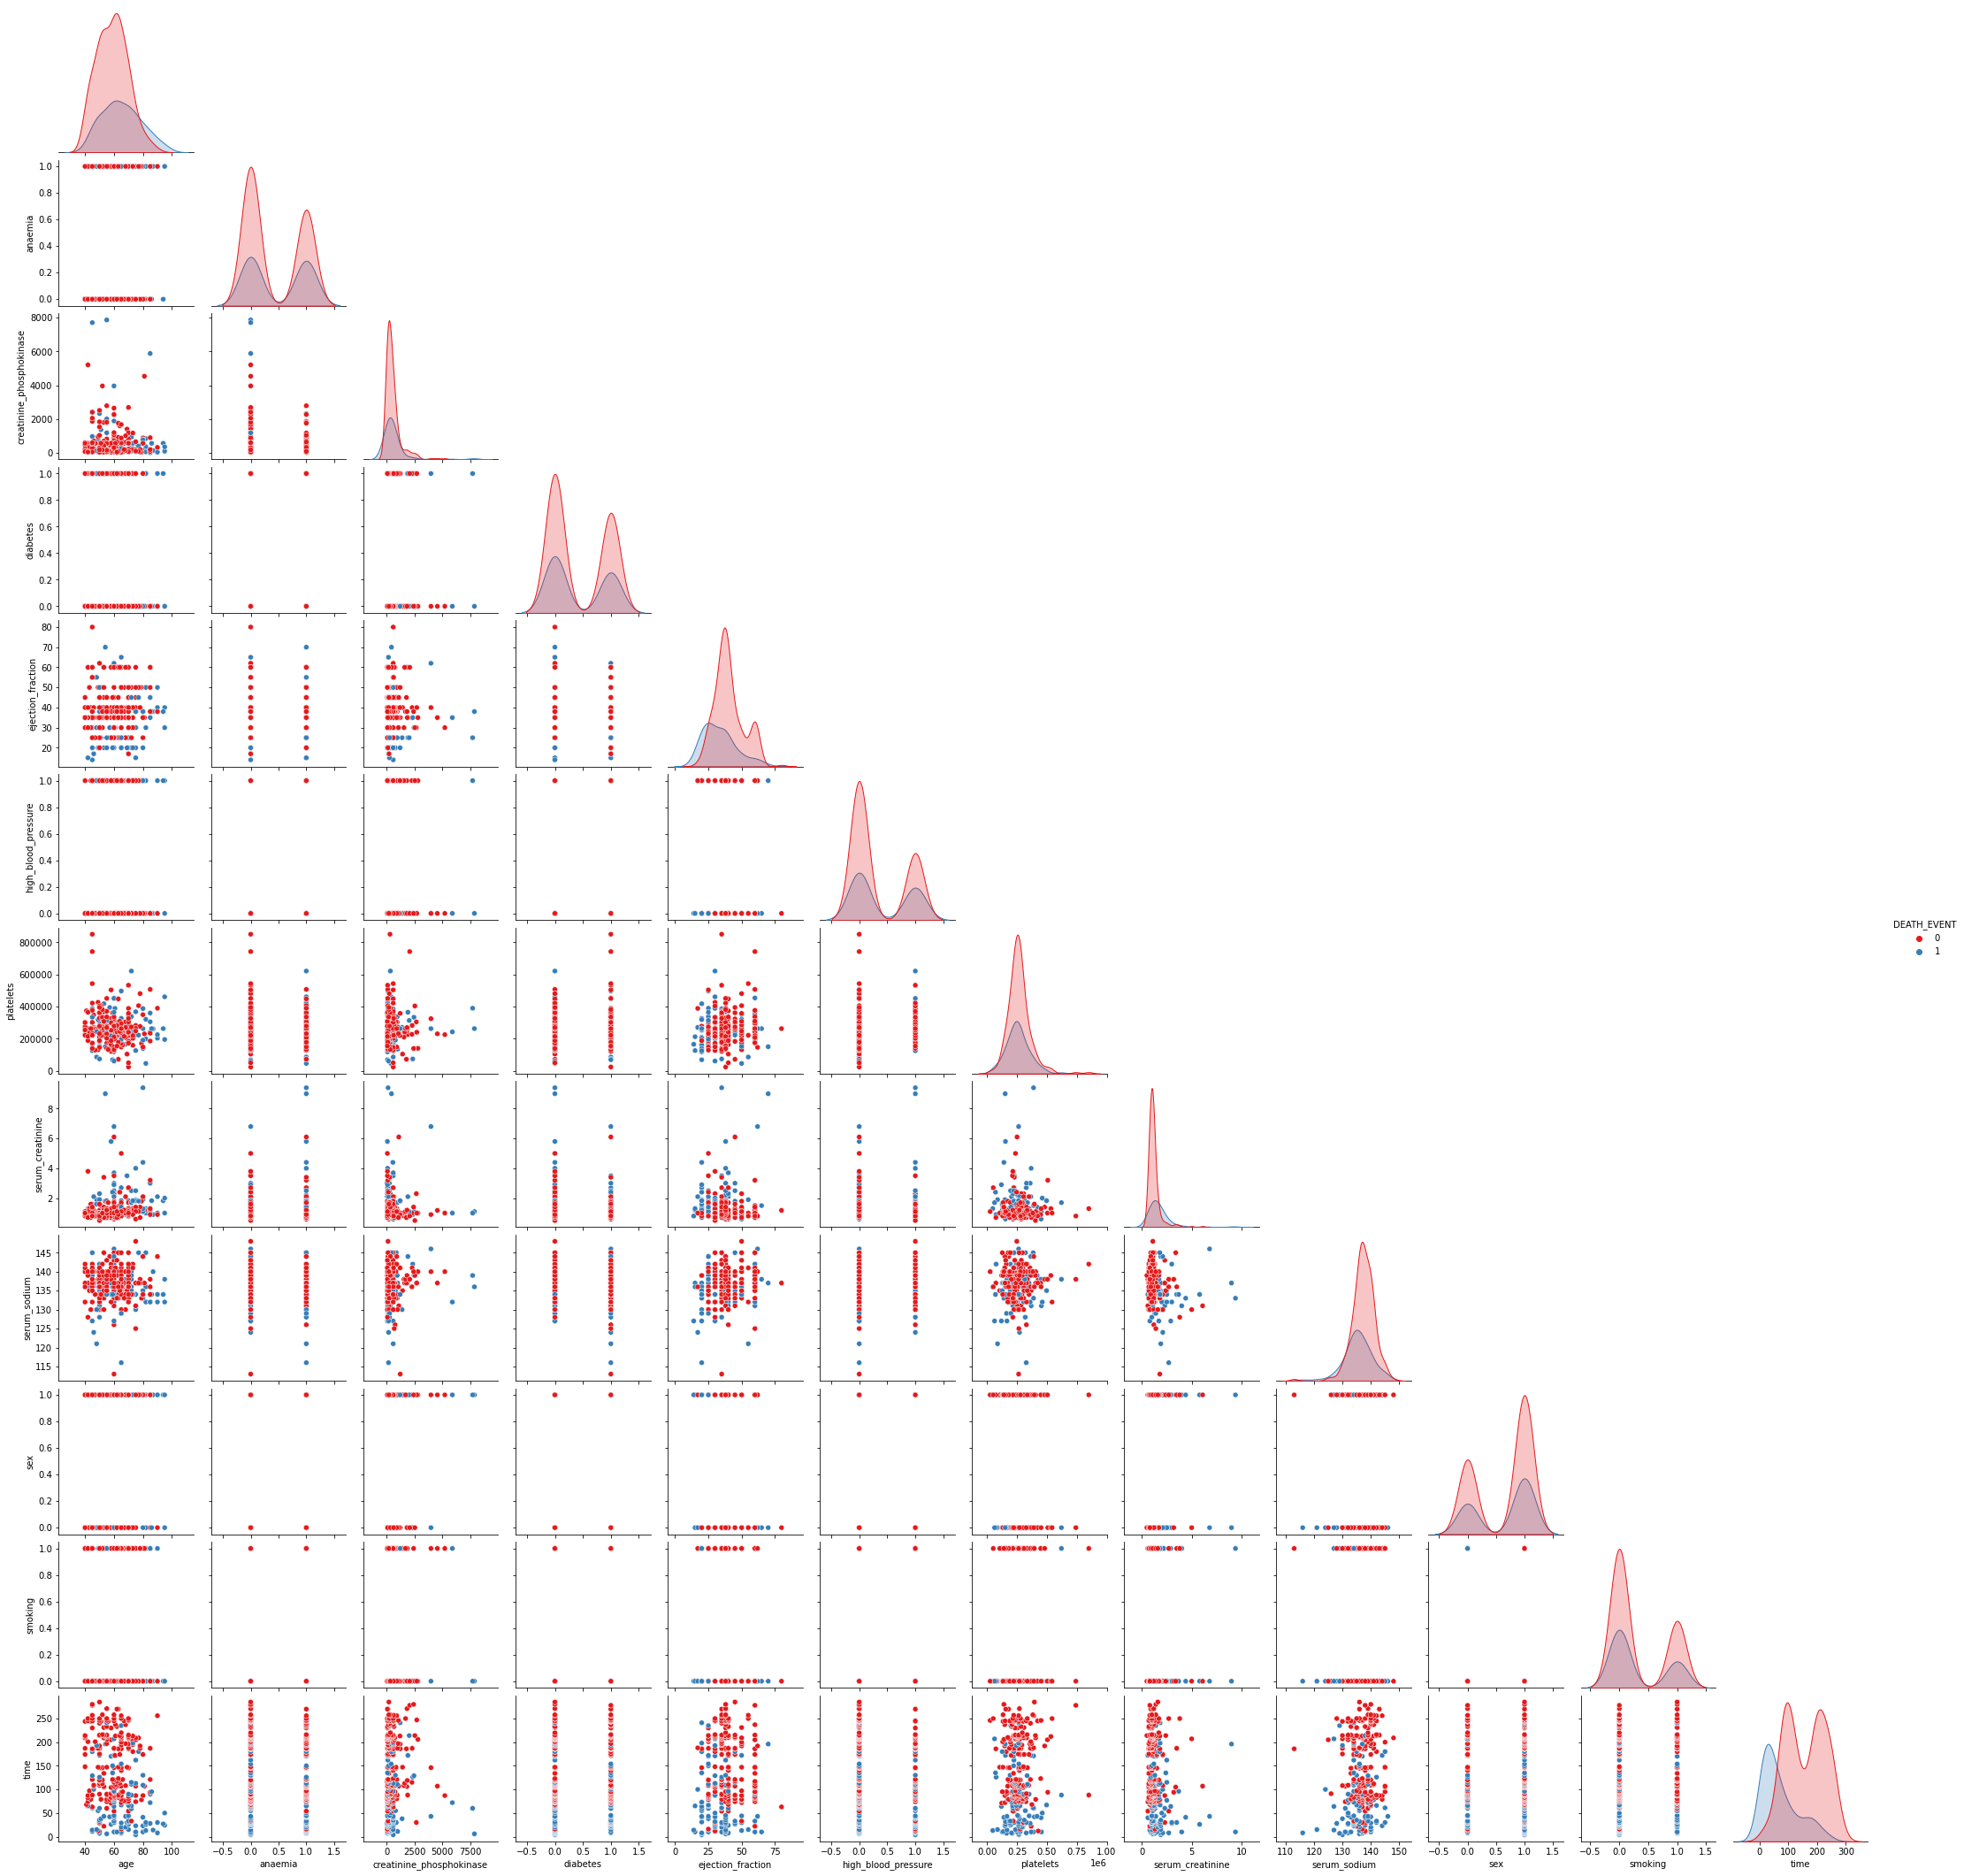

In [54]:
plt.figure(figsize = (15,20))
sns.pairplot(df, hue = 'DEATH_EVENT', palette= 'Set1',corner = 'True')

<AxesSubplot:>

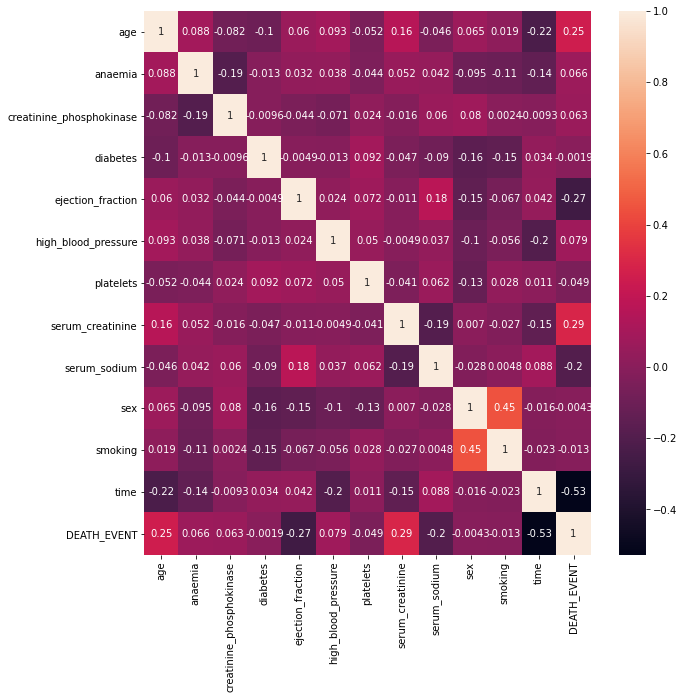

In [55]:
plt.figure(figsize=(10,10))
corr =df.corr()
sns.heatmap(corr,annot=True)

In [56]:
from sklearn.ensemble import RandomForestClassifier
classifierrfc = RandomForestClassifier(n_estimators=100,random_state=0,criterion='gini')
classifierrfc.fit(X_train,y_train)

RandomForestClassifier(random_state=0)

In [57]:
y_predrfc = classifierrfc.predict(X_test)
y_predrfc

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0], dtype=int64)

In [58]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predrfc)

0.8666666666666667

In [59]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predrfc))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91        23
           1       0.67      0.86      0.75         7

    accuracy                           0.87        30
   macro avg       0.81      0.86      0.83        30
weighted avg       0.89      0.87      0.87        30



In [60]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_predrfc))

[[20  3]
 [ 1  6]]


In [61]:
from sklearn.linear_model import LogisticRegression
classifierlr = LogisticRegression(random_state=0,penalty='l2',C=1.2)
classifierlr.fit(X_train,y_train)

LogisticRegression(C=1.2, random_state=0)

In [62]:
y_predlr =classifierlr.predict(X_test)
y_predlr

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0], dtype=int64)

In [63]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predlr)

0.9666666666666667

In [64]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predlr))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.86      0.92         7

    accuracy                           0.97        30
   macro avg       0.98      0.93      0.95        30
weighted avg       0.97      0.97      0.97        30



In [65]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_predlr)

array([[23,  0],
       [ 1,  6]], dtype=int64)

In [66]:
from sklearn.neighbors import KNeighborsClassifier
knn =KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=10)

In [67]:
pred = knn.predict(X_test)
pred

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [68]:
from sklearn.neighbors import KNeighborsClassifier
classifierknn = KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)
classifierknn.fit(X_train,y_train)

KNeighborsClassifier()

In [69]:
y_predknn = classifierknn.predict(X_test)

In [70]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predknn)

0.7666666666666667

In [71]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predknn))

              precision    recall  f1-score   support

           0       0.79      0.96      0.86        23
           1       0.50      0.14      0.22         7

    accuracy                           0.77        30
   macro avg       0.64      0.55      0.54        30
weighted avg       0.72      0.77      0.71        30



In [72]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_predknn))

[[22  1]
 [ 6  1]]


In [77]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(classifierlr,X_train,y_train,cv=15)
scores,scores.mean()

(array([0.83333333, 0.77777778, 0.77777778, 0.83333333, 0.88888889,
        0.83333333, 0.72222222, 0.77777778, 0.88888889, 0.88888889,
        0.83333333, 0.66666667, 0.83333333, 0.83333333, 0.76470588]),
 0.8102396514161221)